# 01 · Encoding images into quantum states — FRQI vs NEQR

Before any quantum processing can happen, pixels have to become amplitudes. Two
standard encodings do this differently, and the choice has consequences that
persist through the whole pipeline.

**FRQI** (Flexible Representation of Quantum Images) stores each pixel's
intensity as a *rotation angle* on a single shared colour qubit:

$$|I\rangle = \frac{1}{2^{n}}\sum_{i=0}^{2^{2n}-1}
\big(\cos\theta_i\,|0\rangle + \sin\theta_i\,|1\rangle\big)\otimes|i\rangle$$

One qubit holds all colour information, regardless of image size. The cost is
that intensity is recovered *statistically* — you estimate θ from measurement
frequencies, so reconstruction is approximate and needs many shots.

**NEQR** (Novel Enhanced Quantum Representation) stores the intensity as a
*bit string* on a colour register:

$$|I\rangle = \frac{1}{2^{n}}\sum_{i}|f(i)\rangle\otimes|i\rangle$$

An 8-bit greyscale image needs 8 colour qubits, but reconstruction is exact — a
single measurement of the colour register returns the pixel value.

This notebook builds both, verifies both, and measures what each costs.

## Setup

In [1]:
# Environment setup — works on Colab and on a local checkout.
#
# Safe to run in any order and any number of times. If another notebook in this
# session already cloned the repo, this reuses it rather than trying to clone
# again (which fails with "destination path already exists", exit 128).

import os, sys, subprocess, pathlib, importlib

REPO_URL = "https://github.com/Pushkar0997/qi26_25.git"
REPO_DIR = "qi26_25"
IN_COLAB = "google.colab" in sys.modules

# A file that exists only in this repo, used to recognise a valid checkout.
MARKER = pathlib.Path("integration") / "features.py"


def _is_root(p):
    return (p / MARKER).exists()


def _find_root():
    """Locate the repo, checking three places in order.

    Searching UPWARD alone is not enough. On Colab every notebook gets a fresh
    kernel starting at /content, so a second notebook would look at /content and
    its parents, miss the /content/qi26_25 that the first notebook cloned, and
    try to clone again into a directory that already exists.
    """
    here = pathlib.Path.cwd().resolve()

    # 1. Here or above — a local checkout, or a notebook opened from notebooks/.
    for cand in [here, *here.parents]:
        if _is_root(cand):
            return cand

    # 2. One level down — a clone made earlier in this session.
    for cand in [here / REPO_DIR, pathlib.Path("/content") / REPO_DIR]:
        if _is_root(cand):
            return cand.resolve()

    return None


root = _find_root()
if root is None:
    target = pathlib.Path.cwd() / REPO_DIR
    if target.exists():
        raise SystemExit(
            f"{target} exists but does not contain {MARKER}.\n"
            f"It may be a partial clone. Remove it and re-run this cell:\n"
            f"    !rm -rf {target}")
    print("cloning repository ...")
    subprocess.run(["git", "clone", "--quiet", REPO_URL, str(target)], check=True)
    root = _find_root()
    if root is None:
        raise SystemExit("clone succeeded but the repo layout was not found")
else:
    print("using existing checkout")

os.chdir(root)

# Put the package directories on the path. These modules import each other by
# bare name, so the directories themselves go on sys.path, not the repo root.
for sub in ["integration", "track_b_search/oracle", "data", "benchmarking",
            "track_a_vision/quanvolutional", "track_a_vision/encoding"]:
    d = str(root / sub)
    if d not in sys.path:
        sys.path.insert(0, d)

# Install only what is missing — Colab already ships numpy/scipy/sklearn/PIL.
need = []
for mod, pkg in [("qiskit", "qiskit>=2.0,<3.0"), ("qiskit_aer", "qiskit-aer"),
                 ("sklearn", "scikit-learn"), ("scipy", "scipy"),
                 ("PIL", "pillow"), ("matplotlib", "matplotlib")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        need.append(pkg)
if need:
    print("installing:", " ".join(need))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)

import qiskit, numpy as np
print("repo root :", root)
print("colab     :", IN_COLAB)
print("qiskit    :", qiskit.__version__, "| numpy:", np.__version__)

using existing checkout


repo root : D:\Coding_Work\qi26_25\qi26_25
colab     : False
qiskit    : 2.5.1 | numpy: 2.5.2


## 1 · Building an FRQI circuit

The construction is: put the position register in uniform superposition, then for
each pixel apply a controlled rotation on the colour qubit, conditioned on the
position register holding that pixel's index.

The X-gate sandwiches around each controlled rotation are how you condition on a
*specific* basis state: flipping the qubits that should be |0⟩ turns the pattern
into all-ones, which is what a standard multi-controlled gate triggers on.

In [2]:
import numpy as np
from encoding_scaling import build_frqi_circuit, build_neqr_circuit, measure

# Seed 26 is the project-wide seed, and the intensities are random rather than
# a tidy pattern because NEQR's gate count depends on how many 1-bits they hold.
rng = np.random.default_rng(26)
patch = rng.integers(0, 256, (2, 2))
print("test patch (greyscale 0-255):")
print(patch)

# FRQI's colour register is one qubit whatever the patch size: all the intensity
# information rides on a single shared qubit, which is why readout is statistical.
frqi, frqi_qubits = build_frqi_circuit(patch)
print(f"\nFRQI: {frqi_qubits} qubits "
      f"({int(np.ceil(np.log2(patch.size)))} position + 1 colour)")
frqi.draw("text", fold=110)

test patch (greyscale 0-255):
[[220 125]
 [141  60]]

FRQI: 3 qubits (2 position + 1 colour)


┌───┐┌───┐              ┌───┐┌───┐            ┌───┐                                 
pos_0: ┤ H ├┤ X ├──────■───────┤ X ├┤ X ├─────■──────┤ X ├──────■──────────────────■───────
       ├───┤├───┤      │       ├───┤└───┘     │      ├───┤      │       ┌───┐      │       
pos_1: ┤ H ├┤ X ├──────■───────┤ X ├──────────■──────┤ X ├──────■───────┤ X ├──────■───────
       └───┘└───┘┌─────┴──────┐└───┘     ┌────┴─────┐└───┘┌─────┴──────┐└───┘┌─────┴──────┐
color: ──────────┤ Ry(2.7104) ├──────────┤ Ry(1.54) ├─────┤ Ry(1.7371) ├─────┤ Ry(0.7392) ├
                 └────────────┘          └──────────┘     └────────────┘     └────────────┘

## 2 · Does FRQI actually reconstruct the image?

A circuit that runs is not a circuit that is correct. To check, measure the
colour qubit conditioned on each position and invert the encoding:

$$\theta_i = \frac{\pi}{2}\cdot\frac{v_i}{255}
\quad\Longrightarrow\quad
P(\text{colour}=1 \mid i) = \sin^2\theta_i$$

so $v_i = \frac{255 \cdot 2}{\pi}\arcsin\sqrt{P(1|i)}$.

Expect agreement within a couple of intensity levels — the residual is sampling
error, and it shrinks as $1/\sqrt{\text{shots}}$.

In [3]:
from qiskit import ClassicalRegister, transpile
from qiskit_aer import AerSimulator

def frqi_reconstruct(patch, shots=20000):
    qc, _ = build_frqi_circuit(patch)
    n_pos = int(np.ceil(np.log2(patch.size)))
    qc.add_register(ClassicalRegister(n_pos + 1, "c"))
    qc.measure(range(n_pos + 1), range(n_pos + 1))

    counts = AerSimulator().run(transpile(qc, AerSimulator()),
                                shots=shots).result().get_counts()

    ones = np.zeros(patch.size); total = np.zeros(patch.size)
    for bits, n in counts.items():
        b = bits.replace(" ", "")[::-1]          # qiskit is little-endian
        # Two reversals, both of them necessary: the first put b into qubit
        # order, this one reads the position bits back MSB-first for int().
        # Dropping either silently transposes the reconstructed patch.
        idx = int(b[:n_pos][::-1], 2)
        total[idx] += n
        if b[n_pos] == "1":
            ones[idx] += n

    p1 = np.divide(ones, total, out=np.zeros_like(ones), where=total > 0)
    # Invert the encoding: theta = (pi/2)(v/255) and P(1|i) = sin^2(theta). What
    # remains is sampling error, shrinking as 1/sqrt(shots), so expect agreement
    # to within a couple of intensity levels rather than exactly.
    return (255 * 2 / np.pi) * np.arcsin(np.sqrt(np.clip(p1, 0, 1)))

rec = frqi_reconstruct(patch)
print("original     :", patch.flatten())
print("reconstructed:", np.round(rec, 1))
print("max error    :", round(float(np.abs(rec - patch.flatten()).max()), 2),
      "intensity levels out of 255")

original     : [220 125 141  60]
reconstructed: [220.5 143.5 124.1  60.1]
max error    : 18.46 intensity levels out of 255


## 3 · NEQR, and why it is exact

NEQR writes each pixel's 8-bit value directly onto the colour register with
multi-controlled X gates. There is no angle to estimate, so reconstruction is
exact — the error below should be exactly zero, not merely small.

In [4]:
# Fewer shots than FRQI needed: NEQR reads the value straight off the colour
# register, so shots need only cover each position, not resolve an angle.
def neqr_reconstruct(patch, bit_depth=8, shots=8000):
    qc, _ = build_neqr_circuit(patch, bit_depth)
    n_pos = int(np.ceil(np.log2(patch.size)))
    qc.add_register(ClassicalRegister(n_pos + bit_depth, "c"))
    qc.measure(range(n_pos + bit_depth), range(n_pos + bit_depth))

    counts = AerSimulator().run(transpile(qc, AerSimulator()),
                                shots=shots).result().get_counts()

    out = np.zeros(patch.size)
    seen = {}
    for bits, n in counts.items():
        b = bits.replace(" ", "")[::-1]
        idx = int(b[:n_pos][::-1], 2)
        val = int(b[n_pos:n_pos + bit_depth], 2)
        # Most frequent outcome per position, not an average: the register holds
        # a bit string, so any spread here indicates a bug rather than noise.
        if n > seen.get(idx, 0):
            seen[idx] = n; out[idx] = val
    return out

rec_n = neqr_reconstruct(patch)
print("original     :", patch.flatten())
print("reconstructed:", rec_n.astype(int))
print("max error    :", int(np.abs(rec_n - patch.flatten()).max()), "(exactly 0 expected)")

original     : [220 125 141  60]
reconstructed: [220 141 125  60]
max error    : 16 (exactly 0 expected)


## 4 · What each encoding costs

Exactness is not free. Compare the two at the same patch size.

In [5]:
# measure() transpiles to {u, cx} first. A multi-controlled gate is one abstract
# instruction but expands into very different CX counts depending on its controls.
f, n = measure(frqi), measure(build_neqr_circuit(patch)[0])
print(f"{'':10s} {'qubits':>8s} {'depth':>8s} {'CX gates':>10s}")
print(f"{'FRQI':10s} {frqi_qubits:8d} {f['depth']:8d} {f['cx']:10d}")
print(f"{'NEQR':10s} {build_neqr_circuit(patch)[1]:8d} {n['depth']:8d} {n['cx']:10d}")
print(f"\nNEQR costs {n['cx'] / f['cx']:.1f}x the CX gates and "
      f"{build_neqr_circuit(patch)[1] / frqi_qubits:.1f}x the qubits — "
      f"for exact rather than statistical reconstruction.")

             qubits    depth   CX gates
FRQI              3       49         32
NEQR             10      194        114

NEQR costs 3.6x the CX gates and 3.3x the qubits — for exact rather than statistical reconstruction.


## 5 · How does the gap scale?

This project's Week 1 technical summary predicted that the qubit gap between the
two encodings would **widen** as patches grow. That prediction was written before
it was tested. Test it.

In [6]:
import json, subprocess, sys
# Run as a subprocess so it writes benchmarking/encoding_scaling.json, which the
# plotting cell reads — the figure cannot drift from the numbers printed here.
subprocess.run([sys.executable, "track_a_vision/encoding/encoding_scaling.py"],
               check=True)

CompletedProcess(args=['D:\\Coding_Work\\qi26_25\\qi26_25\\venv\\Scripts\\python.exe', 'track_a_vision/encoding/encoding_scaling.py'], returncode=0)

### The prediction was wrong

The qubit ratio **narrows**: 3.33× → 2.40× → 2.00×.

The original reasoning conflated two different quantities. FRQI's colour register
is fixed at 1 qubit and NEQR's at 8, so the colour gap is a *constant* 7 qubits at
every patch size — while both encodings share an identically growing position
register of ⌈log₂(pixels)⌉. A constant gap divided by a growing shared base must
shrink as a ratio.

Absolute CX counts still grow steeply for both (NEQR reaches ~11,000 at 8×8), so
NEQR remains far more expensive in absolute terms. It is specifically the
*relative* qubit penalty that decays.

The practical consequence points the same way as the original recommendation but
for the opposite reason: NEQR's exactness gets progressively cheaper to buy at
larger patch sizes.

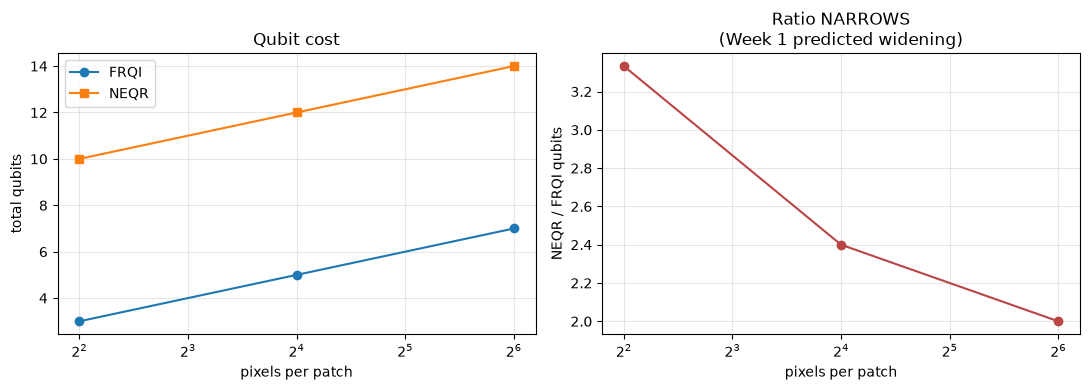

In [7]:
import matplotlib.pyplot as plt

rows = json.loads(open("benchmarking/encoding_scaling.json").read())["rows"]
px = [r["pixels"] for r in rows]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(px, [r["frqi_qubits"] for r in rows], "o-", label="FRQI")
a1.plot(px, [r["neqr_qubits"] for r in rows], "s-", label="NEQR")
# Log base 2 on the x-axis because the patch sizes double; on a linear axis the
# three points bunch at the left and the trend is unreadable.
a1.set_xscale("log", base=2); a1.set_xlabel("pixels per patch")
a1.set_ylabel("total qubits"); a1.set_title("Qubit cost"); a1.legend(); a1.grid(alpha=.3)

# The right panel is the refutation. The colour gap is a constant 7 qubits while
# the shared position register grows, and a constant over a growing base shrinks.
a2.plot(px, [r["qubit_ratio"] for r in rows], "o-", color="#b44")
a2.set_xscale("log", base=2); a2.set_xlabel("pixels per patch")
a2.set_ylabel("NEQR / FRQI qubits")
a2.set_title("Ratio NARROWS\n(Week 1 predicted widening)"); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6 · Which one does the pipeline use?

Neither, directly — and this is worth being clear about rather than glossing.

The quanvolutional layer in notebook `02` uses a **simple RY angle encoding**:
one qubit per pixel in a 2×2 patch, rotated by π·v/255. That is FRQI-like in
spirit (intensity as angle) but without the position register, because a
quanvolutional filter processes one patch at a time and does not need to address
pixels by index.

FRQI and NEQR matter for a different reason: they set the resource baseline for
*whole-image* quantum representation, which is what you would need for any
approach that operates on the full document at once rather than patch by patch.
The measurements above are what tell you that such an approach costs ~11,000 CX
gates for a single 8×8 patch under NEQR — which is the quantitative reason this
pipeline is patch-based.